# 03 · LightGBM : météo horaire, retards courts, météo prévue, incertitude

**Entrées :** `data/processed/dataset_30min.parquet` (notebook 01) et `data/processed/baselines_test_predictions.parquet` (notebook 02).
**Sorties :** `data/processed/lgbm_test_predictions.parquet`, `reports/metrics_lgbm_test.csv`, `models/lgbm_conso.txt`, figures.

## Protocole

Prévision émise le jour D à 10 h pour les 48 pas de D+1. Test de janvier 2025 au dernier jour consolidé avec réentraînement mensuel et 2 jours d'écart. Mêmes horodatages pour tous les modèles. MASE relative au naïf J-7 (2017-11 → 2024).

**Ce qui change côté informations disponibles** (émission à 10 h) : on peut utiliser la consommation du jour D **avant 10 h** (`lag1_rel` pour les créneaux avant 10 h, `dev_matin`).

**Cible :** on prédit l'**écart au niveau récent** (`level7`, moyenne des 7 jours complets T−8 … T−2), ce qui absorbe la baisse tendancielle du niveau.

In [1]:
#!poetry add lightgbm shap

In [2]:
from pathlib import Path
import json, time, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import lightgbm as lgb

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.options.display.max_columns = 40
plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True, "grid.alpha": 0.3})

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW, PROC = ROOT / "data" / "raw", ROOT / "data" / "processed"
REPORTS, FIGS, MODELS_DIR = ROOT / "reports", ROOT / "reports" / "figures", ROOT / "models"
for p in (RAW / "weather_fc", FIGS, MODELS_DIR):
    p.mkdir(parents=True, exist_ok=True)
TZ = "Europe/Paris"


def ts(s):
    return pd.Timestamp(s, tz=TZ)


def save_fig(name):
    plt.savefig(FIGS / f"{name}.png", dpi=130, bbox_inches="tight")

TEST_START = ts("2025-01-01")
VAL_START, VAL_END = ts("2023-01-01"), ts("2025-01-01")        # [début, fin[
VAL_TRAIN_END = ts("2023-01-01")
TRAIN_START_CANDIDATES = ["2013-01-01", "2017-11-01", "2020-07-01"]
HALF_LIVES = [None, 3.0]                                       # pondération par récence (demi-vie en années)
GAP_DAYS = 2
SCALE_PERIOD = (ts("2017-11-01"), ts("2025-01-01"))
ISSUE_HOUR = 10                                                # émission le jour D à 10 h
FC_START = "2022-01-01"                                        # début de la couverture des prévisions météo historiques
FORCE_REFRESH = False

TODAY = pd.Timestamp.today().normalize()

PARAMS = {"objective": "regression", "metric": "l1", "learning_rate": 0.05, "num_leaves": 63,
          "min_data_in_leaf": 100, "feature_fraction": 0.8, "bagging_fraction": 0.8, "bagging_freq": 1,
          "lambda_l2": 1.0, "verbose": -1, "seed": 0}

In [3]:
df = pd.read_parquet(PROC / "dataset_30min.parquet")
for c in ["vac_A", "vac_B", "vac_C", "n_zones_vac"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
y = df["conso"]
TEST_END = df.index[df["source"].eq("cons_def")].max() + pd.Timedelta("30min")     # borne exclusive
bp = pd.read_parquet(PROC / "baselines_test_predictions.parquet") 

print(f"{df.shape[0]:,} lignes | {df.index.min()} → {df.index.max()}")
print(f"Baselines du notebook 02 : {bp.shape} | colonnes : {list(bp.columns)}")


def shift_local(s, days):
    # Valeur de s à (t_local - days jours), indexée sur l'index de s (UTC).
    loc = s.index.tz_convert(TZ).tz_localize(None)
    src = (loc - pd.Timedelta(days=days)).tz_localize(TZ, ambiguous="NaT", nonexistent="shift_forward")
    return pd.Series(s.reindex(src.tz_convert("UTC")).to_numpy(), index=s.index, name=s.name)


def mask_between(index, start, end):
    return np.asarray((index >= start) & (index < end)) # [start, end[


def metrics(yt, yp, scale):
    e = (yp - yt).dropna()
    yt = yt.loc[e.index]
    return {"MAE": e.abs().mean(), "RMSE": np.sqrt((e ** 2).mean()), "MAPE %": (e.abs() / yt).mean() * 100,
            "biais": e.mean(), "MASE": e.abs().mean() / scale, "n": len(e)}


SCALE = (y - shift_local(y, 7)).abs()[mask_between(y.index, *SCALE_PERIOD)].mean()
print(f"Dénominateur MASE : {SCALE:,.0f} MW")

240,458 lignes | 2013-01-01 00:00:00+00:00 → 2026-09-19 12:30:00+00:00
Baselines du notebook 02 : (26206, 7) | colonnes : ['y', 'naive_7d', 'mean_4w', 'naive_7d_temp', 'reg_slot', 'rte_j1', 'rte_j']
Dénominateur MASE : 3,569 MW


## 1. Météo prévue : télécharger et comparer à l'observée

L'API de **prévisions historiques** d'Open-Meteo conserve, pour chaque heure passée, la prévision issue des exécutions récentes des modèles. Ce n'est pas exactement une prévision J-1 émise à 10 h (les échéances sont plus courtes), donc le coût réel de l'incertitude météo est **sous-estimé** ici.

Même agrégation qu'au notebook 01 : 10 agglomérations pondérées par la population, puis interpolation à 30 min. Téléchargement ville par ville et année par année, avec cache dans `data/raw/weather_fc/`.

In [4]:
CITIES = {   # nom: (latitude, longitude, poids ~ population de l'agglomération, en millions)
    "Paris": (48.8566, 2.3522, 10.9), "Lyon": (45.7640, 4.8357, 2.3), "Marseille": (43.2965, 5.3698, 1.9),
    "Toulouse": (43.6047, 1.4442, 1.4), "Lille": (50.6292, 3.0573, 1.2), "Bordeaux": (44.8378, -0.5792, 1.3),
    "Nantes": (47.2184, -1.5536, 1.0), "Strasbourg": (48.5734, 7.7521, 0.8), "Nice": (43.7102, 7.2620, 1.0),
    "Rennes": (48.1173, -1.6778, 0.75),
}
HOURLY = ["temperature_2m", "relative_humidity_2m", "wind_speed_10m", "cloud_cover", "shortwave_radiation"]
WCOLS = ["temp_nat", "hum_nat", "wind_nat", "cloud_nat", "rad_nat"]
FC_URL = "https://historical-forecast-api.open-meteo.com/v1/forecast"
PATH_FC = RAW / "meteo_forecast_openmeteo.parquet"
weights = pd.Series({k: v[2] for k, v in CITIES.items()})


def fetch_openmeteo(url, lat, lon, start, end, variables, max_retry=6):
    params = dict(latitude=lat, longitude=lon, start_date=start, end_date=end,
                  hourly=",".join(variables), timezone="UTC")
    for attempt in range(max_retry):
        r = requests.get(url, params=params, timeout=90)
        if r.status_code == 200:
            d_ = pd.DataFrame(r.json()["hourly"])
            d_["time"] = pd.to_datetime(d_["time"], utc=True)
            return d_.set_index("time")
        if r.status_code == 429:
            wait = 30 * (attempt + 1)
            print(f"   429 — pause {wait}s")
            time.sleep(wait)
            continue
        r.raise_for_status()
    raise RuntimeError("Open-Meteo : trop de tentatives.")


def fetch_city_year_fc(city, lat, lon, year):
    start = max(pd.Timestamp(FC_START), pd.Timestamp(f"{year}-01-01"))
    end = min(pd.Timestamp(f"{year}-12-31"), TODAY - pd.Timedelta(days=1))
    if start > end:
        return None
    cache = RAW / "weather_fc" / f"{city}_{year}.parquet"
    if cache.exists():
        return pd.read_parquet(cache)
    d_ = fetch_openmeteo(FC_URL, lat, lon, start.strftime("%Y-%m-%d"), end.strftime("%Y-%m-%d"), HOURLY)
    if year < TODAY.year:
        d_.to_parquet(cache)
    time.sleep(0.5)
    return d_


HAS_FC = True
try:
    if PATH_FC.exists() and not FORCE_REFRESH:
        meteo_fc = pd.read_parquet(PATH_FC)
        print(f"Déjà présent : {PATH_FC.name}")
    else:
        frames = []
        for city, (lat, lon, _) in CITIES.items():
            print(f"{city}")
            for year in range(int(FC_START[:4]), TODAY.year + 1):
                d_ = fetch_city_year_fc(city, lat, lon, year)
                if d_ is not None:
                    frames.append(d_.assign(city=city))
        meteo_fc = pd.concat(frames).sort_index()
        meteo_fc.to_parquet(PATH_FC)
    print(f"{meteo_fc['city'].nunique()} villes | {meteo_fc.index.min()} → {meteo_fc.index.max()} | {len(meteo_fc):,} lignes")
except Exception as e: # API inaccessible : on continue en mode oracle seul
    HAS_FC = False
    print("Prévisions météo indisponibles :", e, "\nOn continue avec les baselines uniquement.")

Déjà présent : meteo_forecast_openmeteo.parquet
10 villes | 2022-01-01 00:00:00+00:00 → 2026-09-19 23:00:00+00:00 | 413,520 lignes


Prévu - observé, moyenne nationale pondérée, période commune :


,biais,MAE,RMSE,corr,n
temp_nat,0.683,0.738,0.978,0.995,82415.0
hum_nat,-3.341,3.788,5.203,0.966,82415.0
wind_nat,-1.693,1.919,2.678,0.899,82415.0
cloud_nat,4.373,9.249,14.722,0.875,82415.0
rad_nat,-4.195,11.459,28.213,0.992,82415.0


L'écart observé au notebook 01 sur Paris seul (MAE ~1 °C, biais +0,8 °C) se confirme-t-il sur la moyenne nationale ?


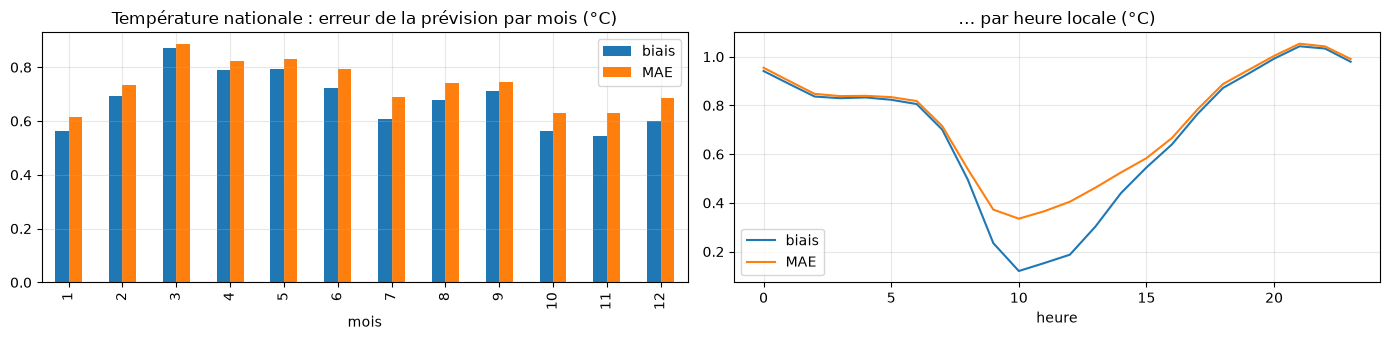

In [5]:
def weighted_national(m):
    m = m.copy()
    w = m.pop("city").map(weights)
    valid = m[HOURLY].notna().mul(w, axis=0)
    num = m[HOURLY].fillna(0).mul(w, axis=0).groupby(level=0).sum()
    den = valid.groupby(level=0).sum()
    return (num / den).sort_index()


wt_obs = df[WCOLS].copy() # météo observée, déjà agrégée et interpolée
if HAS_FC:
    nat_fc = weighted_national(meteo_fc)
    nat_fc.columns = WCOLS
    wt_fc = nat_fc.resample("30min").interpolate(method="time").reindex(df.index)
else:
    wt_fc = wt_obs.copy() * np.nan

if HAS_FC:
    common = wt_fc["temp_nat"].notna() & wt_obs["temp_nat"].notna()
    rows = {}
    for c in WCOLS:
        e = (wt_fc[c] - wt_obs[c])[common]
        rows[c] = {"biais": e.mean(), "MAE": e.abs().mean(), "RMSE": np.sqrt((e ** 2).mean()),
                   "corr": wt_fc[c][common].corr(wt_obs[c][common]), "n": int(common.sum())}
    print("Prévu - observé, moyenne nationale pondérée, période commune :")
    display(pd.DataFrame(rows).T.round(3))

    e_t = (wt_fc["temp_nat"] - wt_obs["temp_nat"])[common]
    m_loc = e_t.index.tz_convert(TZ).month
    h_loc = e_t.index.tz_convert(TZ).hour
    fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
    pd.DataFrame({"biais": e_t.groupby(m_loc).mean(), "MAE": e_t.abs().groupby(m_loc).mean()}).plot.bar(ax=axes[0])
    axes[0].set_title("Température nationale : erreur de la prévision par mois (°C)"); axes[0].set_xlabel("mois")
    pd.DataFrame({"biais": e_t.groupby(h_loc).mean(), "MAE": e_t.abs().groupby(h_loc).mean()}).plot(ax=axes[1])
    axes[1].set_title("… par heure locale (°C)"); axes[1].set_xlabel("heure")
    plt.tight_layout(); save_fig("meteo_prevue_vs_observee")
    print("L'écart observé au notebook 01 sur Paris seul (MAE ~1 °C, biais +0,8 °C) se confirme-t-il sur la moyenne nationale ?")

## 2. Variables

Toutes les variables sont construites à partir de deux jeux de météo :
- `wt` = météo **au moment cible** (observée en mode oracle, prévue en mode prévision) ;
- la météo **passée** (jours ≤ D) reste toujours l'observée : `hdd7`, `dtemp_7j`, et les jours T−1, T−2 dans les moyennes lissées.

| Groupe | Variables |
|---|---|
| Calendrier | heure, jour de semaine, mois, jour de l'année, férié, pont, veille/lendemain de férié, vacances par zone |
| Météo à t | température, humidité, vent, nébulosité, rayonnement, température à t−3 h et t−6 h |
| Météo du jour | température lissée `te` (EWM), moyenne 3 jours, min/max du jour, `dT = t − te`, rayonnement moyen du jour |
| Niveau | `hdd7` (chauffage des 7 jours du niveau) ; `level7` sert de base à la cible (pas de variable brute) |
| Retards | `lag1_rel` (créneaux avant 10 h), `lag2_rel`, `lag7_rel`, `lag14_rel` (écart au niveau courant) ; `lag2/7/14_dev` (écart au niveau de la période de référence) ; jours de référence fériés/ponts |
| Nowcast | `dev_matin` : écart de la moyenne 0 h - 9 h 30 de D à celle de D−7 |
| Écart de météo | `dtemp_7j` = température cible − température observée 7 jours avant |

In [6]:
def build_features(d, wt):
    y_ = d["conso"]
    local = d.index.tz_convert(TZ)
    day = local.tz_localize(None).normalize()
    hh = np.asarray(local.hour + local.minute / 60)
    early = hh < ISSUE_HOUR # créneaux dont le retard de 24 h est connu à l'émission

    def to_rows(s):
        return pd.Series(s.reindex(day).to_numpy(), index=d.index)

    X = pd.DataFrame(index=d.index)

    # Calendrier
    X["heure"] = hh
    X["jour_semaine"] = local.dayofweek.to_numpy()
    X["mois"] = local.month.to_numpy()
    X["jour_annee"] = local.dayofyear.to_numpy()
    X["is_holiday"] = d["is_holiday"].astype(float)
    X["is_bridge"] = d["is_bridge"].astype(float)
    for c in ["vac_A", "vac_B", "vac_C", "n_zones_vac"]:
        X[c] = d[c]
    hol_d = d["is_holiday"].astype(float).groupby(day).max().asfreq("D")
    X["veille_ferie"] = to_rows(hol_d.shift(-1))
    X["lendemain_ferie"] = to_rows(hol_d.shift(1))

    # Météo au moment cible
    for c in WCOLS:
        X[c] = wt[c]
    X["temp_l3h"] = wt["temp_nat"].shift(6)
    X["temp_l6h"] = wt["temp_nat"].shift(12)
    dt_obs = d["temp_nat"].groupby(day).mean().asfreq("D")
    dt_tgt = wt["temp_nat"].groupby(day).mean().asfreq("D")
    te_obs = dt_obs.ewm(alpha=0.5).mean().where(dt_obs.notna())
    te = to_rows(0.5 * dt_tgt + 0.5 * te_obs.shift(1)) # EWM(alpha=0,5) dont le dernier jour est la cible
    X["te"] = te
    X["t_roll3"] = to_rows((dt_tgt + dt_obs.shift(1) + dt_obs.shift(2)) / 3)
    X["t_min_j"] = to_rows(wt["temp_nat"].groupby(day).min().asfreq("D"))
    X["t_max_j"] = to_rows(wt["temp_nat"].groupby(day).max().asfreq("D"))
    X["dT"] = wt["temp_nat"] - te
    X["dtemp_7j"] = wt["temp_nat"] - shift_local(d["temp_nat"], 7)
    X["rad_jour"] = to_rows(wt["rad_nat"].groupby(day).mean().asfreq("D"))
    hdd_obs = (17 - te_obs).clip(lower=0)
    X["hdd7"] = to_rows(hdd_obs.shift(2).rolling(7, min_periods=7).mean())

    # Niveau et retards (uniquement des informations disponibles à l'émission)
    dy = y_.groupby(day).mean().asfreq("D")
    level7 = to_rows(dy.shift(2).rolling(7, min_periods=7).mean()) # jours T-8 ... T-2
    X["level7"] = level7
    lag = {k: shift_local(y_, k) for k in (1, 2, 7, 14)}
    lvl_prev = {k: shift_local(level7, k) for k in (2, 7, 14)}
    X["lag1_rel"] = (lag[1] - level7).where(early)
    X["lag2_rel"] = lag[2] - level7
    X["lag7_rel"] = lag[7] - level7
    X["lag14_rel"] = lag[14] - level7
    X["lag2_dev"] = lag[2] - lvl_prev[2]
    X["lag7_dev"] = lag[7] - lvl_prev[7]
    X["lag14_dev"] = lag[14] - lvl_prev[14]
    for k in (2, 7):
        X[f"lag{k}_ferie"] = shift_local(X["is_holiday"], k)
        X[f"lag{k}_pont"] = shift_local(X["is_bridge"], k)

    # Nowcast : écart matinal de D (0 h - 9 h 30) par rapport à D-7
    m_early = y_[early].groupby(day[early]).mean().asfreq("D")
    X["dev_matin"] = to_rows((m_early - m_early.shift(7)).shift(1))
    return X


X_obs = build_features(df, wt_obs)
FEATS = [c for c in X_obs.columns if c != "level7"]
print(f"{len(FEATS)} variables :\n{FEATS}")
(X_obs[FEATS].isna().mean() * 100).round(1).sort_values(ascending=False).head(8).to_frame("% NaN").T

39 variables :
['heure', 'jour_semaine', 'mois', 'jour_annee', 'is_holiday', 'is_bridge', 'vac_A', 'vac_B', 'vac_C', 'n_zones_vac', 'veille_ferie', 'lendemain_ferie', 'temp_nat', 'hum_nat', 'wind_nat', 'cloud_nat', 'rad_nat', 'temp_l3h', 'temp_l6h', 'te', 't_roll3', 't_min_j', 't_max_j', 'dT', 'dtemp_7j', 'rad_jour', 'hdd7', 'lag1_rel', 'lag2_rel', 'lag7_rel', 'lag14_rel', 'lag2_dev', 'lag7_dev', 'lag14_dev', 'lag2_ferie', 'lag2_pont', 'lag7_ferie', 'lag7_pont', 'dev_matin']


,lag1_rel,lag14_dev,dtemp_7j,lag14_rel,lag7_dev,hdd7,lag7_rel,lag7_ferie
% NaN,58.4,0.4,0.3,0.3,0.3,0.2,0.2,0.2


### Test de non-fuite

Émission à 10 h le jour D pour le jour T = D+1. On efface toute la consommation **à partir de D 10 h**, on reconstruit toutes les variables, et on vérifie que celles du jour T sont inchangées.

In [7]:
T0 = pd.Timestamp("2025-03-12")
cutoff = ts("2025-03-11 10:00") # D = 11 mars, 10 h
sub = df.loc[ts("2024-12-01"):ts("2025-04-01")]
sub_mod = sub.copy()
sub_mod.loc[sub_mod.index >= cutoff, "conso"] = np.nan

Xa, Xb = build_features(sub, sub[WCOLS]), build_features(sub_mod, sub_mod[WCOLS])
sel = sub.index.tz_convert(TZ).tz_localize(None).normalize() == T0
assert sel.sum() >= 46, "jour cible introuvable"
assert np.allclose(Xa.loc[sel].to_numpy(dtype=float), Xb.loc[sel].to_numpy(dtype=float), equal_nan=True), "FUITE détectée"
print("Aucune variable du jour", T0.date(), "ne dépend de la consommation postérieure à l'émission (D 10 h)")

Aucune variable du jour 2025-03-12 ne dépend de la consommation postérieure à l'émission (D 10 h)


In [8]:
X_fc = build_features(df, wt_fc) if HAS_FC else None
FC_OK = wt_fc["temp_nat"].notna().to_numpy() # lignes disposant d'une prévision météo


def train_weights(index, ref_end, half_life):
    if half_life is None:
        return None
    age_years = np.asarray((ref_end - index).total_seconds()) / (365.25 * 86400)
    return 0.5 ** (age_years / half_life)


def fit_lgb(X, y, mask, rounds, half_life=None, ref_end=None, params=PARAMS):
    tgt = y - X["level7"]
    tr = mask & tgt.notna().to_numpy()
    w = train_weights(X.index[tr], ref_end, half_life)
    return lgb.train(params, lgb.Dataset(X.loc[tr, FEATS], label=tgt[tr], weight=w), num_boost_round=rounds)


def fit_es(X, y, train_mask, valid_mask, half_life, ref_end, params=PARAMS, max_rounds=2000):
    # Entraîne avec arrêt anticipé sur la validation : renvoie le modèle et le nombre d'itérations retenu.
    tgt = y - X["level7"]
    tr, va = train_mask & tgt.notna().to_numpy(), valid_mask & tgt.notna().to_numpy()
    w = train_weights(X.index[tr], ref_end, half_life)
    dtr = lgb.Dataset(X.loc[tr, FEATS], label=tgt[tr], weight=w)
    dva = lgb.Dataset(X.loc[va, FEATS], label=tgt[va], reference=dtr)
    model = lgb.train(params, dtr, max_rounds, valid_sets=[dva], callbacks=[lgb.early_stopping(50, verbose=False)])
    return model, model.best_iteration


def predict_lgb(model, X):
    p = pd.Series(model.predict(X[FEATS]), index=X.index) + X["level7"]
    return p.where(X["temp_nat"].notna()) # pas de prévision sans météo, comme au notebook 02

## 3. Ablation avec LightGBM : date de début et pondération par récence

On refait l'expérience du notebook 02 avec un modèle capable de mieux exploiter les données anciennes : entraînement < 2023, validation 2023-2024, arrêt anticipé pour fixer le nombre d'arbres. Deux axes : la date de début (2013 / novembre 2017 / juillet 2020) et une **pondération par récence** (demi-vie de 3 ans) pour tenir compte de la dérive du niveau.

*Note :* l'arrêt anticipé utilise la même période de validation que l'évaluation, ce qui est légèrement optimiste, mais de la même façon pour toutes les configurations.

In [9]:
val_mask = mask_between(X_obs.index, VAL_START, VAL_END)
rows, best_iters = [], {}
for start in TRAIN_START_CANDIDATES:
    for hl in HALF_LIVES:
        tm = mask_between(X_obs.index, ts(start), VAL_TRAIN_END)
        t0 = time.time()
        model, n_it = fit_es(X_obs, y, tm, val_mask, hl, VAL_TRAIN_END)
        p = predict_lgb(model, X_obs.loc[val_mask])
        best_iters[(start, hl)] = n_it
        rows.append({"début": start, "demi-vie (ans)": hl if hl else "aucune", "arbres": n_it,
                     **metrics(y[val_mask], p, SCALE)})
        print(f"  {start} | demi-vie {hl} : {n_it} arbres, {time.time() - t0:.0f}s")

abl = pd.DataFrame(rows)
same_pts = X_obs.loc[val_mask, "temp_nat"].notna()
abl.loc[len(abl)] = {"début": "(réf.) naive_7d", "demi-vie (ans)": "", "arbres": 0,
                     **metrics(y[val_mask], shift_local(y, 7)[val_mask].where(same_pts), SCALE)}
abl.loc[len(abl)] = {"début": "(réf.) RTE J-1", "demi-vie (ans)": "", "arbres": 0,
                     **metrics(y[val_mask], df.loc[val_mask, "prevision_j1"].where(same_pts), SCALE)}
display(abl.round({"MAE": 0, "RMSE": 0, "MAPE %": 2, "biais": 0, "MASE": 3}))

grid = abl[~abl["début"].astype(str).str.startswith("(réf.)")]
best = grid.loc[grid["MAE"].idxmin()]
TRAIN_START_FINAL = best["début"]
HALF_LIFE_FINAL = None if best["demi-vie (ans)"] == "aucune" else float(best["demi-vie (ans)"])
N_ROUNDS = int(max(100, best["arbres"]))
print(f"\nConfiguration retenue : début {TRAIN_START_FINAL}, demi-vie {HALF_LIFE_FINAL}, {N_ROUNDS} arbres")

  2013-01-01 | demi-vie None : 1999 arbres, 39s
  2013-01-01 | demi-vie 3.0 : 2000 arbres, 38s
  2017-11-01 | demi-vie None : 1999 arbres, 32s
  2017-11-01 | demi-vie 3.0 : 1732 arbres, 32s
  2020-07-01 | demi-vie None : 1647 arbres, 27s
  2020-07-01 | demi-vie 3.0 : 1980 arbres, 31s


,début,demi-vie (ans),arbres,MAE,RMSE,MAPE %,biais,MASE,n
0,2013-01-01,aucune,1999,855.0,1182.0,1.66,14.0,0.240,35088
1,2013-01-01,3.0,2000,853.0,1189.0,1.66,13.0,0.239,35088
2,2017-11-01,aucune,1999,881.0,1233.0,1.71,-24.0,0.247,35088
3,2017-11-01,3.0,1732,886.0,1237.0,1.72,-28.0,0.248,35088
4,2020-07-01,aucune,1647,999.0,1438.0,1.93,2.0,0.280,35088
5,2020-07-01,3.0,1980,1010.0,1446.0,1.95,-3.0,0.283,35088
6,(réf.) naive_7d,,0,3340.0,4918.0,6.27,-104.0,0.936,35084
7,(réf.) RTE J-1,,0,1341.0,1675.0,2.71,-1139.0,0.376,35084



Configuration retenue : début 2013-01-01, demi-vie 3.0, 2000 arbres


## 4. Test : trois modes de météo

Réentraînement **mensuel** (*rolling origin*, 2 jours d'écart) sur la configuration retenue. Trois évaluations :

| Mode | Entraînement | Météo à la prédiction | Interprétation |
|---|---|---|---|
| `lgb_oracle` | observée | observée | borne haute |
| `lgb_A` | observée | **prévue** | modèle entraîné en observé, servi avec des prévisions : cas opérationnel simple |
| `lgb_B` | **prévue** (depuis 2022) | prévue | le modèle apprend les défauts des prévisions, mais dispose de moins d'historique |

L'écart `lgb_oracle` → `lgb_A` chiffre le **coût de l'incertitude météo** ; `lgb_A` → `lgb_B` mesure ce qu'on gagne à entraîner sur des prévisions.

In [10]:
def rolling_backtest_lgb(fits, preds, y, test_start, test_end, train_start, rounds, half_life):
    # fits : {nom: (X_fit, masque_lignes_valides)} ; preds : {nom_sortie: (nom_fit, X_pred)}
    test_end = test_end.tz_convert(TZ)
    months = list(pd.date_range(test_start, test_end - pd.Timedelta("30min"), freq="MS"))
    bounds = months[1:] + [test_end]
    out = {k: [] for k in preds}
    for ms, me in zip(months, bounds):
        train_end = ms - pd.Timedelta(days=GAP_DAYS)
        models = {}
        for name, (Xf, valid) in fits.items():
            tm = mask_between(Xf.index, train_start, train_end) & valid
            models[name] = fit_lgb(Xf, y, tm, rounds, half_life, ref_end=train_end)
        pm = mask_between(df.index, ms, me)
        for k, (fit_name, Xp) in preds.items():
            out[k].append(predict_lgb(models[fit_name], Xp.loc[pm]))
        print(f"  {ms.strftime('%Y-%m')} ok", end="")
    print()
    return {k: pd.concat(v) for k, v in out.items()}


TRAIN_START_TS = ts(TRAIN_START_FINAL)
all_rows = np.ones(len(df), dtype=bool)
fits = {"obs": (X_obs, all_rows)}
preds = {"lgb_oracle": ("obs", X_obs)}
if HAS_FC:
    fits["fc"] = (X_fc, FC_OK)
    preds.update({"lgb_A": ("obs", X_fc), "lgb_B": ("fc", X_fc)})

t0 = time.time()
# Mode B : on n'entraîne que sur les lignes ayant une prévision météo (à partir de 2022)
res_bt = rolling_backtest_lgb(fits, preds, y, TEST_START, TEST_END, TRAIN_START_TS, N_ROUNDS, HALF_LIFE_FINAL)
print(f"Durée : {time.time() - t0:.0f}s")

F3 = bp.copy()
for k, s in res_bt.items():
    F3[k] = s.reindex(F3.index)
test_mask = np.asarray((F3.index >= TEST_START) & (F3.index < TEST_END))

  2025-01 ok  2025-02 ok  2025-03 ok  2025-04 ok  2025-05 ok  2025-06 ok  2025-07 ok  2025-08 ok  2025-09 ok  2025-10 ok  2025-11 ok  2025-12 ok  2026-01 ok  2026-02 ok  2026-03 ok  2026-04 ok  2026-05 ok  2026-06 ok
Durée : 2027s


Points de test communs : 26,202 sur 26,206


,MAE,RMSE,MAPE %,biais,MASE,n
Naïf J-7,3666.0,5265.0,6.83,154.0,1.027,26202
Naïf J-7 + temp.*,2084.0,2856.0,4.11,-119.0,0.584,26202
Régression par créneau*,1505.0,1953.0,3.00,-8.0,0.422,26202
RTE J-1,1379.0,1718.0,2.74,-1055.0,0.386,26202
LightGBM — météo observée*,870.0,1191.0,1.66,-124.0,0.244,26202
"LightGBM A — entraîné obs., servi prévu",1053.0,1424.0,2.00,-537.0,0.295,26202
LightGBM B — entraîné prévu,971.0,1382.0,1.83,-178.0,0.272,26202


* = météo observée (oracle) : borne haute des performances


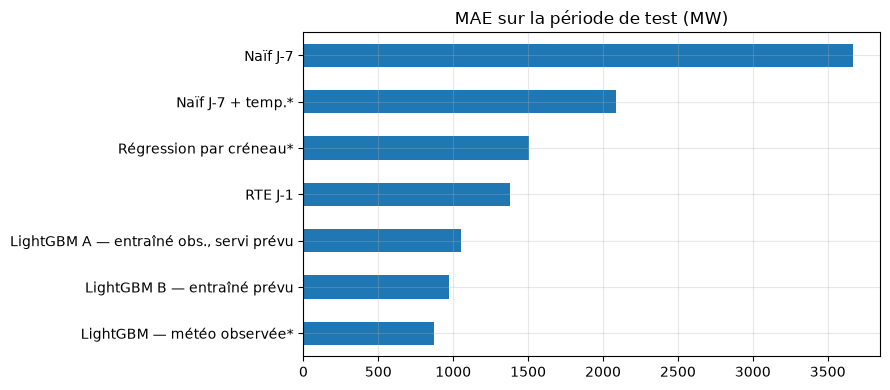

In [11]:
MODELS3 = {"naive_7d": "Naïf J-7", "naive_7d_temp": "Naïf J-7 + temp.*", "reg_slot": "Régression par créneau*",
           "rte_j1": "RTE J-1"}
if "rte_j1_debiaise" in F3.columns:
    MODELS3["rte_j1_debiaise"] = "RTE J-1 débiaisé (28 j)"
MODELS3["lgb_oracle"] = "LightGBM — météo observée*"
if HAS_FC:
    MODELS3["lgb_A"] = "LightGBM A — entraîné obs., servi prévu"
    MODELS3["lgb_B"] = "LightGBM B — entraîné prévu"

EV3 = F3.loc[test_mask, ["y"] + list(MODELS3)].dropna()
print(f"Points de test communs : {len(EV3):,} sur {test_mask.sum():,}")
res3 = pd.DataFrame({MODELS3[m]: metrics(EV3["y"], EV3[m], SCALE) for m in MODELS3}).T.astype({"n": int})
display(res3.round({"MAE": 0, "RMSE": 0, "MAPE %": 2, "biais": 0, "MASE": 3}))
print("* = météo observée (oracle) : borne haute des performances")

fig, ax = plt.subplots(figsize=(9, 4))
res3["MAE"].sort_values().plot.barh(ax=ax, color="tab:blue")
ax.set_title("MAE sur la période de test (MW)"); ax.set_ylabel("")
plt.tight_layout(); save_fig("lgbm_mae_modeles")
REPORTS.mkdir(exist_ok=True)
res3.to_csv(REPORTS / "metrics_lgbm_test.csv")

## 5. Où l'erreur a-t-elle bougé ?

Comparaison avec la régression du notebook 02 et RTE J-1, sur les axes qui posaient problème : heure, température, type de jour.

MAE (MW) par type de jour :


,Régression par créneau*,RTE J-1,LightGBM — météo observée*,"LightGBM A — entraîné obs., servi prévu",LightGBM B — entraîné prévu,n
type_jour,,,,,,
dimanche,1441.0,1466.0,891.0,1145.0,966.0,3738
férié,1794.0,2129.0,1460.0,1525.0,1611.0,816
pont,1415.0,1212.0,995.0,949.0,1062.0,336
samedi,1336.0,1455.0,812.0,968.0,874.0,3696
semaine,1543.0,1312.0,847.0,1031.0,962.0,17616


MAE (MW) par tranche de température nationale (°C) :


,Régression par créneau*,RTE J-1,LightGBM — météo observée*,"LightGBM A — entraîné obs., servi prévu",LightGBM B — entraîné prévu
tranche_T,,,,,
<0,2993.0,1505.0,1427.0,2047.0,2056.0
0-5,1707.0,1477.0,1318.0,1607.0,1606.0
5-10,1366.0,1200.0,1026.0,1395.0,1179.0
10-15,1428.0,1378.0,826.0,975.0,874.0
15-20,1485.0,1427.0,637.0,699.0,674.0
20-25,1360.0,1475.0,612.0,654.0,667.0
>25,1943.0,1535.0,812.0,817.0,829.0


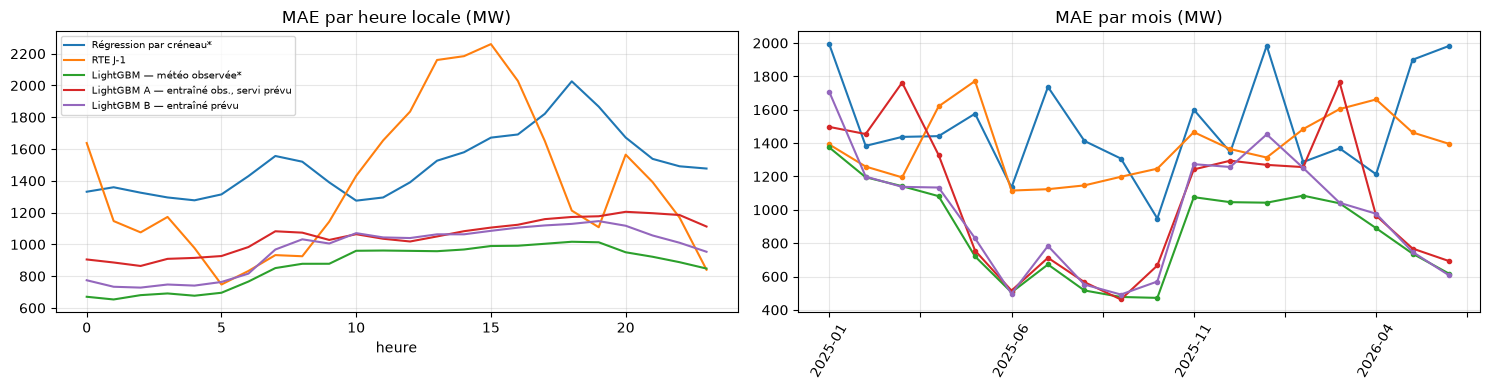

In [12]:
loc_ix = EV3.index.tz_convert(TZ)
E = EV3.copy()
E["heure"] = loc_ix.hour
E["mois"] = loc_ix.strftime("%Y-%m")
flags = df.loc[EV3.index, ["is_holiday", "is_bridge"]]
E["type_jour"] = np.select(
    [flags["is_holiday"].to_numpy(), flags["is_bridge"].to_numpy(), loc_ix.dayofweek == 6, loc_ix.dayofweek == 5],
    ["férié", "pont", "dimanche", "samedi"], default="semaine")
E["tranche_T"] = pd.cut(df.loc[EV3.index, "temp_nat"], [-np.inf, 0, 5, 10, 15, 20, 25, np.inf],
                        labels=["<0", "0-5", "5-10", "10-15", "15-20", "20-25", ">25"])

show = [m for m in ["reg_slot", "rte_j1", "lgb_oracle", "lgb_A", "lgb_B"] if m in MODELS3]
abs_err = {m: (E[m] - E["y"]).abs() for m in show}

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for m in show:
    abs_err[m].groupby(E["heure"]).mean().plot(ax=axes[0], label=MODELS3[m])
    abs_err[m].groupby(E["mois"]).mean().plot(ax=axes[1], label=MODELS3[m], marker="o", ms=3)
axes[0].set_title("MAE par heure locale (MW)"); axes[0].legend(fontsize=7); axes[0].set_xlabel("heure")
axes[1].set_title("MAE par mois (MW)"); axes[1].tick_params(axis="x", rotation=60); axes[1].set_xlabel("")
plt.tight_layout(); save_fig("lgbm_mae_heure_mois")

tab_jour = pd.DataFrame({MODELS3[m]: abs_err[m].groupby(E["type_jour"]).mean() for m in show})
tab_temp = pd.DataFrame({MODELS3[m]: abs_err[m].groupby(E["tranche_T"], observed=True).mean() for m in show})
print("MAE (MW) par type de jour :"); display(tab_jour.round(0).assign(n=E["type_jour"].value_counts()))
print("MAE (MW) par tranche de température nationale (°C) :"); display(tab_temp.round(0))

,MAE pointe (MW),MAPE pointe %,biais pointe (MW)
Naïf J-7,3725.0,6.13,147.0
Naïf J-7 + temp.*,2054.0,3.60,-125.0
Régression par créneau*,1466.0,2.57,-401.0
RTE J-1,1418.0,2.56,-1174.0
LightGBM — météo observée*,912.0,1.56,-111.0
"LightGBM A — entraîné obs., servi prévu",1085.0,1.84,-530.0
LightGBM B — entraîné prévu,1064.0,1.78,-278.0


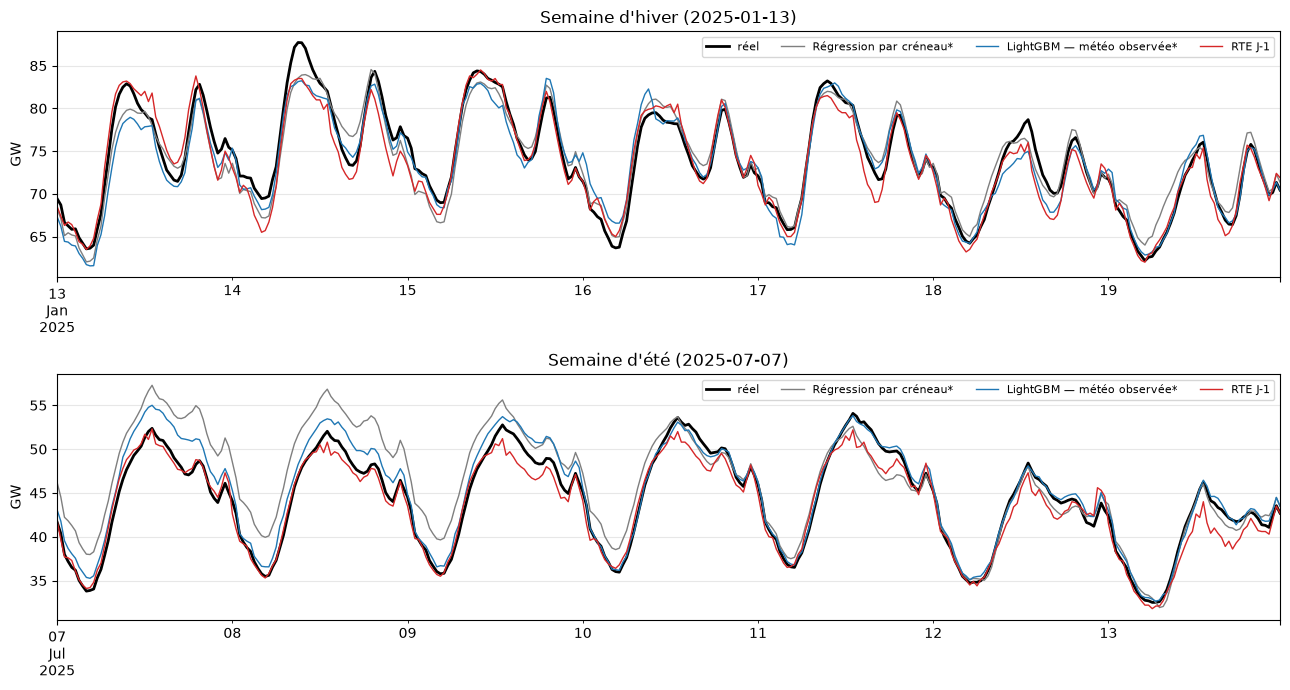

In [13]:
# Pointe journalière
day_ev = loc_ix.tz_localize(None).normalize()
peak = EV3.groupby(day_ev).max()
rows = {}
for m in MODELS3:
    e = peak[m] - peak["y"]
    rows[MODELS3[m]] = {"MAE pointe (MW)": e.abs().mean(), "MAPE pointe %": (e.abs() / peak["y"]).mean() * 100,
                        "biais pointe (MW)": e.mean()}
display(pd.DataFrame(rows).T.round({"MAE pointe (MW)": 0, "MAPE pointe %": 2, "biais pointe (MW)": 0}))

# Deux semaines types : hiver et été
wk = EV3.copy()
wk.index = wk.index.tz_convert(TZ)
periods = [("2025-01-13", "2025-01-19", "Semaine d'hiver"), ("2025-07-07", "2025-07-13", "Semaine d'été")]
fig, axes = plt.subplots(len(periods), 1, figsize=(13, 7))
for ax, (a, b, title) in zip(axes, periods):
    w = wk.loc[a:b]
    if w.empty:
        ax.set_title(f"{title} : pas de données"); continue
    (w["y"] / 1000).plot(ax=ax, color="k", lw=2, label="réel")
    for m, c in [("reg_slot", "tab:gray"), ("lgb_oracle", "tab:blue"), ("rte_j1", "tab:red")]:
        (w[m] / 1000).plot(ax=ax, color=c, lw=1, label=MODELS3[m])
    ax.set_title(f"{title} ({a})"); ax.set_ylabel("GW"); ax.legend(fontsize=8, ncol=4); ax.set_xlabel("")
plt.tight_layout(); save_fig("lgbm_semaines_types")

## 6. Que regarde le modèle ?

Importance en *gain* et valeurs SHAP d'un modèle entraîné sur toutes les données disponibles avant le test (avec 2 jours d'écart). Ce même modèle est ensuite sauvegardé pour l'API.

Variables les plus utiles : ['lag7_rel', 'lag1_rel', 'dev_matin', 'jour_semaine', 'dtemp_7j', 'hdd7']


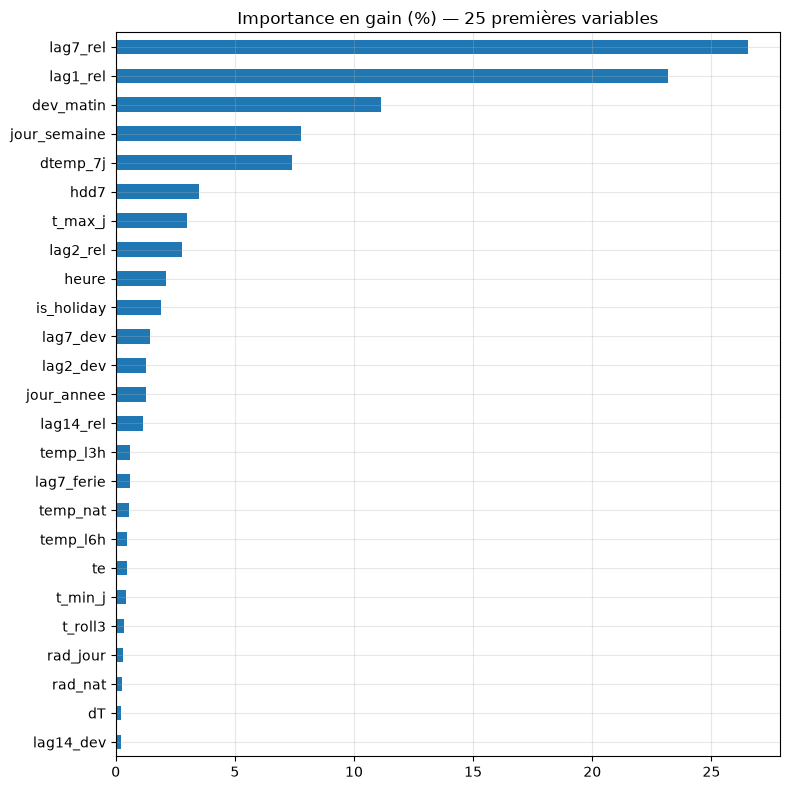

In [14]:
train_end_final = TEST_START - pd.Timedelta(days=GAP_DAYS)
tm_final = mask_between(X_obs.index, TRAIN_START_TS, train_end_final)
FINAL_MODEL = fit_lgb(X_obs, y, tm_final, N_ROUNDS, HALF_LIFE_FINAL, ref_end=train_end_final)

imp = pd.Series(FINAL_MODEL.feature_importance("gain"), index=FEATS)
imp = (imp / imp.sum() * 100).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 8))
imp.tail(25).plot.barh(ax=ax, color="tab:blue")
ax.set_title("Importance en gain (%) — 25 premières variables")
plt.tight_layout(); save_fig("lgbm_importance")
print("Variables les plus utiles :", list(imp.tail(6).index[::-1]))

c:\Users\baptm\Downloads\conso-rte\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


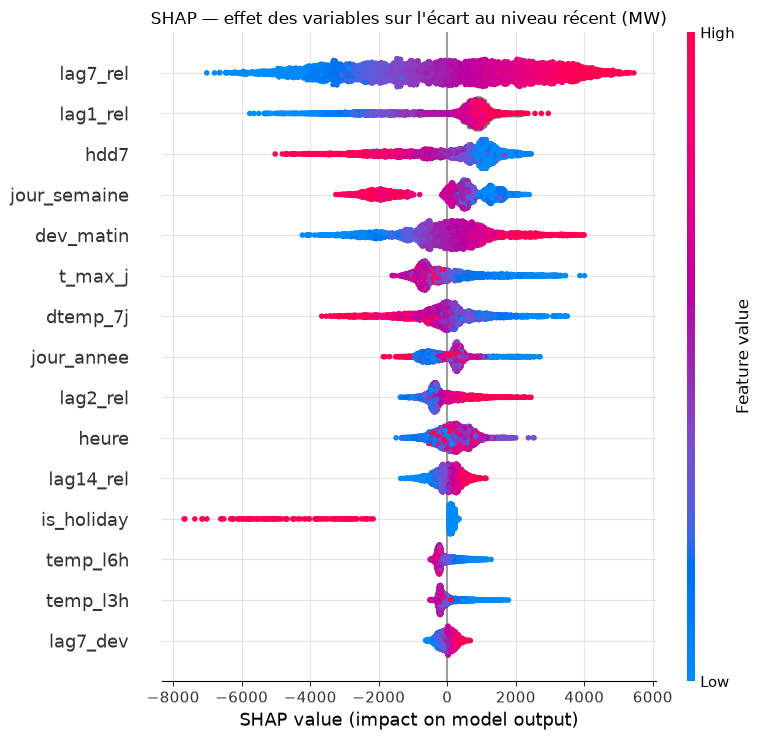

In [15]:
import shap
rng = np.random.default_rng(0)
test_idx = np.flatnonzero(mask_between(X_obs.index, TEST_START, TEST_END) & X_obs["temp_nat"].notna().to_numpy())
samp = X_obs.iloc[rng.choice(test_idx, size=min(4000, len(test_idx)), replace=False)][FEATS]
sv = shap.TreeExplainer(FINAL_MODEL).shap_values(samp)
shap.summary_plot(sv, samp, show=False, max_display=15)
plt.title("SHAP — effet des variables sur l'écart au niveau récent (MW)")
plt.tight_layout(); save_fig("lgbm_shap")
plt.show()

## 7. Prévision probabiliste : intervalle à 90 %

Trois modèles de **régression quantile** (5 %, 50 %, 95 %) entraînés une seule fois sur les données antérieures au test (météo observée). On vérifie :
- la **couverture** : la part des points réels dans [q05, q95] doit être proche de 90 % ;
- la **largeur** moyenne de l'intervalle ;
- la **perte pinball** de chaque quantile.

Un modèle entraîné une seule fois vieillit : une couverture inférieure à 90 % en fin de période signalerait une dérive à corriger (réentraînement, recalibrage conforme).

Couverture de [q05, q95] : 67.5% (cible : 90 %)
Largeur moyenne : 2,284 MW
Perte pinball (MW) : {0.05: 149, 0.5: 438, 0.95: 169}
MAE de la médiane : 876 MW


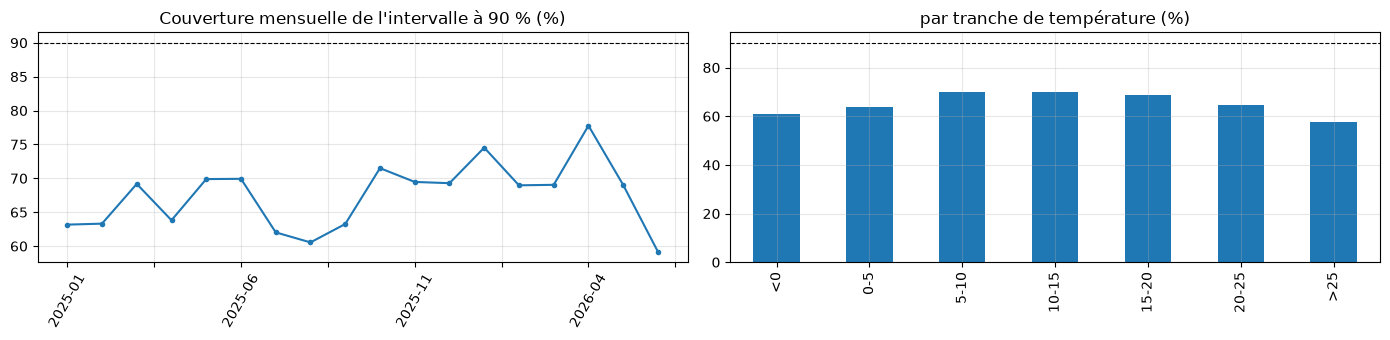

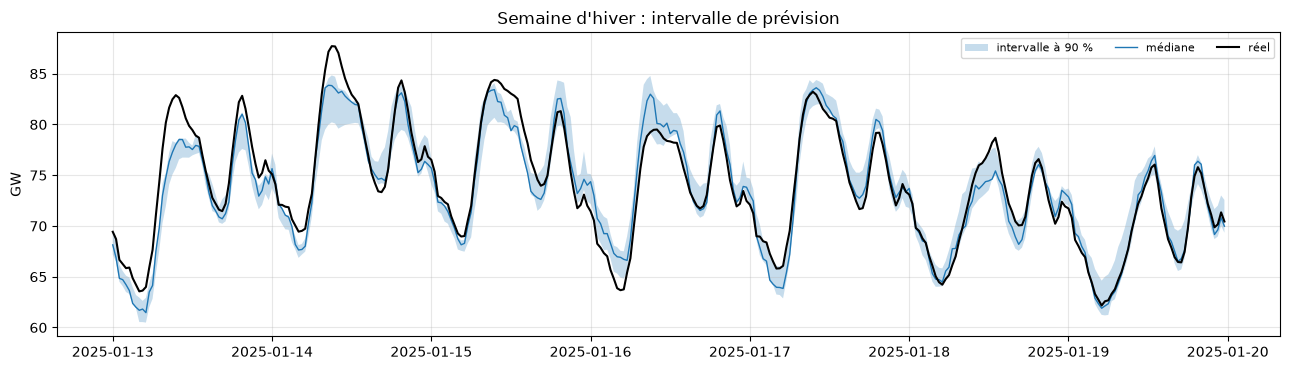

In [16]:
QS = [0.05, 0.5, 0.95]
qmodels = {}
for q in QS:
    prm = {**PARAMS, "objective": "quantile", "alpha": q, "metric": "quantile"}
    qmodels[q] = fit_lgb(X_obs, y, tm_final, N_ROUNDS, HALF_LIFE_FINAL, ref_end=train_end_final, params=prm)

Xq = X_obs.loc[EV3.index]
Q = pd.DataFrame({q: predict_lgb(qmodels[q], Xq) for q in QS})
Q = pd.DataFrame(np.sort(Q.to_numpy(), axis=1), index=Q.index, columns=QS) # évite les croisements de quantiles
yq = EV3["y"]

inside = (yq >= Q[0.05]) & (yq <= Q[0.95])
pin = {q: np.mean(np.maximum(q * (yq - Q[q]), (q - 1) * (yq - Q[q]))) for q in QS}
print(f"Couverture de [q05, q95] : {inside.mean():.1%} (cible : 90 %)")
print(f"Largeur moyenne : {(Q[0.95] - Q[0.05]).mean():,.0f} MW")
print("Perte pinball (MW) :", {q: round(v) for q, v in pin.items()})
print(f"MAE de la médiane : {(yq - Q[0.5]).abs().mean():,.0f} MW")

cov_m = inside.groupby(EV3.index.tz_convert(TZ).strftime("%Y-%m")).mean() * 100
cov_t = inside.groupby(E["tranche_T"], observed=True).mean() * 100
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
cov_m.plot(ax=axes[0], marker="o", ms=3); axes[0].axhline(90, color="k", ls="--", lw=0.8)
axes[0].set_title("Couverture mensuelle de l'intervalle à 90 % (%)"); axes[0].tick_params(axis="x", rotation=60); axes[0].set_xlabel("")
cov_t.plot.bar(ax=axes[1]); axes[1].axhline(90, color="k", ls="--", lw=0.8)
axes[1].set_title("par tranche de température (%)"); axes[1].set_xlabel("")
plt.tight_layout(); save_fig("lgbm_couverture")

w = pd.concat([yq, Q], axis=1)
w.index = w.index.tz_convert(TZ)
w = w.loc["2025-01-13":"2025-01-19"]
if len(w):
    fig, ax = plt.subplots(figsize=(13, 3.8))
    ax.fill_between(w.index, w[0.05] / 1000, w[0.95] / 1000, alpha=0.25, label="intervalle à 90 %")
    ax.plot(w.index, w[0.5] / 1000, lw=1, label="médiane")
    ax.plot(w.index, w["y"] / 1000, "k", lw=1.5, label="réel")
    ax.set_ylabel("GW"); ax.set_title("Semaine d'hiver : intervalle de prévision"); ax.legend(ncol=3, fontsize=8)
    plt.tight_layout(); save_fig("lgbm_intervalle_semaine")

### 7.b Calibration conforme de l'intervalle

**Constat :** la couverture est de 67,5 % au lieu de 90 % (58 à 78 % selon le mois, 58 à 70 % selon la température). Les intervalles sont uniformément trop étroits. Deux causes probables : (1) des modèles quantiles à 2 000 arbres, sur-ajustés à l'entraînement ; (2) un calcul en météo observée, alors qu'en exploitation la météo est prévue.

**Correction : régression quantile conforme (CQR), stratifiée par température.**
1. Modèles q05 / q95 entraînés **avant 2023** (météo observée).
2. Sur **2023-2024**, on les applique avec la **météo prévue** et on mesure de combien le réel sort de l'intervalle (« scores »).
3. On élargit l'intervalle du quantile à 90 % de ces scores, séparément pour le froid (< 5 °C), le doux (5-15 °C) et le chaud (> 15 °C), car l'incertitude météo pèse beaucoup plus l'hiver.
4. On applique le résultat au test, sans jamais l'y ajuster.

Le test est loin de la période de calibration (2025-2026 contre 2023-2024) : si la couverture dérive dans le temps, il faudra recalibrer régulièrement.

Élargissement conforme (MW) par régime de température : {'froid': 2104, 'doux': 930, 'chaud': 454}


,couverture %,largeur moyenne (MW)
non calibré (modèles < 2023),65.9,2675.1
calibré (CQR par température),87.7,4364.2


Rappel : intervalle du §7 (modèles < 2025, météo observée) = 67,5 % de couverture.


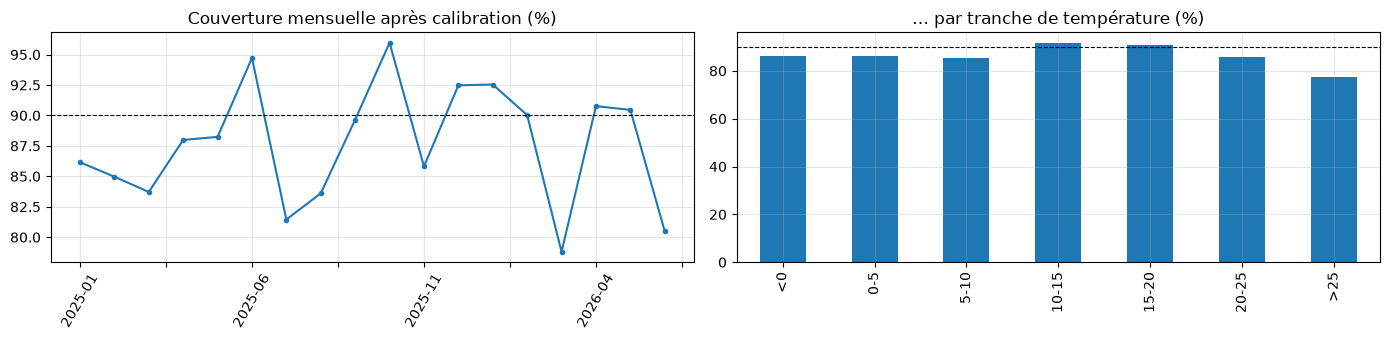

In [18]:
Q_ROUNDS = 800
qm_cal = {}
tm_q = mask_between(X_obs.index, TRAIN_START_TS, VAL_TRAIN_END - pd.Timedelta(days=GAP_DAYS))
for q in (0.05, 0.95):
    prm = {**PARAMS, "objective": "quantile", "alpha": q, "metric": "quantile"}
    qm_cal[q] = fit_lgb(X_obs, y, tm_q, Q_ROUNDS, HALF_LIFE_FINAL, ref_end=VAL_TRAIN_END, params=prm)

X_op = X_fc if HAS_FC else X_obs # conditions d'exploitation : météo prévue si disponible


def interval(Xp):
    lo, hi = predict_lgb(qm_cal[0.05], Xp), predict_lgb(qm_cal[0.95], Xp)
    return np.minimum(lo, hi), np.maximum(lo, hi)


def groupe_temp(Xp):
    return pd.Series(np.select([Xp["te"] < 5, Xp["te"] < 15], ["froid", "doux"], "chaud"), index=Xp.index)


# 1) calibration sur 2023-2024
vm = mask_between(X_op.index, VAL_START, VAL_END) & X_op["temp_nat"].notna().to_numpy() & y.notna().to_numpy()
Xv = X_op.loc[vm]
lo_v, hi_v = interval(Xv)
score = np.maximum(lo_v - y.loc[Xv.index], y.loc[Xv.index] - hi_v)
gv = groupe_temp(Xv)
alpha = 0.10
qhat = {}
for g in ["froid", "doux", "chaud"]:
    s = score[(gv == g) & score.notna()].to_numpy()
    k = min(1.0, np.ceil((len(s) + 1) * (1 - alpha)) / len(s))
    qhat[g] = float(np.quantile(s, k, method="higher"))
print("Élargissement conforme (MW) par régime de température :", {g: round(v) for g, v in qhat.items()})

# 2) application au test
Xt = X_op.loc[EV3.index]
lo_t, hi_t = interval(Xt)
gt = groupe_temp(Xt)
adj = gt.map(qhat)
lo_c, hi_c = lo_t - adj, hi_t + adj
yt = EV3["y"]

rows = {}
for nom, (lo, hi) in {"non calibré (modèles < 2023)": (lo_t, hi_t), "calibré (CQR par température)": (lo_c, hi_c)}.items():
    ins = (yt >= lo) & (yt <= hi)
    rows[nom] = {"couverture %": ins.mean() * 100, "largeur moyenne (MW)": (hi - lo).mean()}
display(pd.DataFrame(rows).T.round(1))
print("Rappel : intervalle du §7 (modèles < 2025, météo observée) = 67,5 % de couverture.")

ins_c = (yt >= lo_c) & (yt <= hi_c)
cov_m = ins_c.groupby(EV3.index.tz_convert(TZ).strftime("%Y-%m")).mean() * 100
cov_t = ins_c.groupby(E["tranche_T"], observed=True).mean() * 100
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
cov_m.plot(ax=axes[0], marker="o", ms=3); axes[0].axhline(90, color="k", ls="--", lw=0.8)
axes[0].set_title("Couverture mensuelle après calibration (%)"); axes[0].tick_params(axis="x", rotation=60); axes[0].set_xlabel("")
cov_t.plot.bar(ax=axes[1]); axes[1].axhline(90, color="k", ls="--", lw=0.8)
axes[1].set_title("par tranche de température (%)"); axes[1].set_xlabel("")
plt.tight_layout(); save_fig("lgbm_couverture_calibree")

## 8. Robustesse du résultat : deux vérifications

Le tableau de la section 4 est très favorable à LightGBM. Avant de l'afficher dans le README, on vérifie deux points fragiles.

**8.1 Jeu d'informations.** `lag1_rel` et `dev_matin`, deux des trois variables les plus importantes, utilisent la consommation du jour D **avant 10 h**. C'est légitime si la prévision est émise à 10 h, mais on ignore à quelle heure RTE émet sa prévision J-1 : le modèle a peut-être plus d'informations que RTE. On mesure ce que devient le résultat **sans aucune information du jour D** (émission à la fin de D−1).

**8.2 Biais de la météo prévue.** La section 1 a montré que l'erreur de température prévue est presque entièrement un **biais** (≈ +0,7 °C), fort la nuit et le soir (~+1 °C) et quasi nul vers 10 h. Un modèle entraîné sur l'observé (mode A) est faussé par ce biais. On le corrige **par heure locale**, en estimant le biais sur 2022-2024 uniquement.

*Les modèles de cette section sont entraînés une seule fois avant le test (pas de réentraînement mensuel) : les comparaisons entre eux sont valables, mais les chiffres absolus sont un peu plus pessimistes que ceux de la section 4.*

In [19]:
# 8.1 — Le résultat dépend-il des informations de la matinée de D ?
FEATS_SANS_D = [f for f in FEATS if f not in ("lag1_rel", "dev_matin")]


def fit_lgb_feats(feats, X, y, mask, rounds, half_life, ref_end):
    tgt = y - X["level7"]
    tr = mask & tgt.notna().to_numpy()
    w = train_weights(X.index[tr], ref_end, half_life)
    return lgb.train(PARAMS, lgb.Dataset(X.loc[tr, feats], label=tgt[tr], weight=w), num_boost_round=rounds)


def predict_feats(model, feats, X):
    p = pd.Series(model.predict(X[feats]), index=X.index) + X["level7"]
    return p.where(X["temp_nat"].notna())


m_sans = fit_lgb_feats(FEATS_SANS_D, X_obs, y, tm_final, N_ROUNDS, HALF_LIFE_FINAL, train_end_final)
idx = EV3.index
cmp_d = {"RTE J-1": EV3["rte_j1"],
         "Avec infos de D — météo observée": predict_lgb(FINAL_MODEL, X_obs.loc[idx]),
         "Sans infos de D — météo observée": predict_feats(m_sans, FEATS_SANS_D, X_obs.loc[idx])}
if HAS_FC:
    cmp_d["Avec infos de D — météo prévue (A)"] = predict_lgb(FINAL_MODEL, X_fc.loc[idx])
    cmp_d["Sans infos de D — météo prévue (A)"] = predict_feats(m_sans, FEATS_SANS_D, X_fc.loc[idx])

tab = pd.DataFrame({k: metrics(EV3["y"], v, SCALE) for k, v in cmp_d.items()}).T.astype({"n": int})
display(tab.round({"MAE": 0, "RMSE": 0, "MAPE %": 2, "biais": 0, "MASE": 3}))

early = (E["heure"] < ISSUE_HOUR).to_numpy()
by_slot = pd.DataFrame({k: (v - EV3["y"]).abs().groupby(np.where(early, "0 h - 9 h 30", "10 h - 23 h 30")).mean()
                        for k, v in cmp_d.items()}).T
print("MAE (MW) selon le créneau cible :")
display(by_slot.round(0))

,MAE,RMSE,MAPE %,biais,MASE,n
RTE J-1,1379.0,1718.0,2.74,-1055.0,0.386,26202
Avec infos de D — météo observée,882.0,1203.0,1.69,-122.0,0.247,26202
Sans infos de D — météo observée,946.0,1286.0,1.82,-136.0,0.265,26202
Avec infos de D — météo prévue (A),1064.0,1435.0,2.02,-534.0,0.298,26202
Sans infos de D — météo prévue (A),1147.0,1543.0,2.19,-581.0,0.321,26202


MAE (MW) selon le créneau cible :


,0 h - 9 h 30,10 h - 23 h 30
RTE J-1,1059.0,1607.0
Avec infos de D — météo observée,753.0,974.0
Sans infos de D — météo observée,919.0,966.0
Avec infos de D — météo prévue (A),963.0,1136.0
Sans infos de D — météo prévue (A),1137.0,1155.0


In [20]:
# 8.2 — Correction du biais de la température prévue, par heure locale (estimé sur 2022-2024 seulement)
if HAS_FC:
    fit_period = (mask_between(wt_fc.index, ts(FC_START), TEST_START - pd.Timedelta(days=GAP_DAYS))
                  & wt_fc["temp_nat"].notna().to_numpy() & wt_obs["temp_nat"].notna().to_numpy())
    heure_loc = pd.Series(wt_fc.index.tz_convert(TZ).hour, index=wt_fc.index)
    biais_h = (wt_fc["temp_nat"] - wt_obs["temp_nat"])[fit_period].groupby(heure_loc[fit_period]).mean()
    print("Biais de la température prévue par heure locale (°C) :", biais_h.round(2).to_dict())

    wt_fc_adj = wt_fc.copy()
    wt_fc_adj["temp_nat"] = wt_fc["temp_nat"] - heure_loc.map(biais_h)
    X_fc_adj = build_features(df, wt_fc_adj)

    cmp_t = {"RTE J-1": EV3["rte_j1"],
             "Météo observée (oracle)": predict_lgb(FINAL_MODEL, X_obs.loc[idx]),
             "Météo prévue (A)": predict_lgb(FINAL_MODEL, X_fc.loc[idx]),
             "Météo prévue, température débiaisée": predict_lgb(FINAL_MODEL, X_fc_adj.loc[idx])}
    tab_t = pd.DataFrame({k: metrics(EV3["y"], v, SCALE) for k, v in cmp_t.items()}).T.astype({"n": int})
    display(tab_t.round({"MAE": 0, "RMSE": 0, "MAPE %": 2, "biais": 0, "MASE": 3}))

    by_temp = pd.DataFrame({k: (v - EV3["y"]).abs().groupby(E["tranche_T"], observed=True).mean()
                            for k, v in cmp_t.items()})
    print("MAE (MW) par tranche de température nationale :")
    display(by_temp.round(0))
else:
    print("Prévisions météo indisponibles : section sautée.")

Biais de la température prévue par heure locale (°C) : {0: 0.86, 1: 0.8, 2: 0.7, 3: 0.67, 4: 0.67, 5: 0.66, 6: 0.64, 7: 0.55, 8: 0.37, 9: 0.15, 10: 0.07, 11: 0.11, 12: 0.15, 13: 0.27, 14: 0.44, 15: 0.53, 16: 0.59, 17: 0.7, 18: 0.77, 19: 0.82, 20: 0.89, 21: 0.94, 22: 0.94, 23: 0.91}


,MAE,RMSE,MAPE %,biais,MASE,n
RTE J-1,1379.0,1718.0,2.74,-1055.0,0.386,26202
Météo observée (oracle),882.0,1203.0,1.69,-122.0,0.247,26202
Météo prévue (A),1064.0,1435.0,2.02,-534.0,0.298,26202
"Météo prévue, température débiaisée",929.0,1263.0,1.78,-262.0,0.260,26202


MAE (MW) par tranche de température nationale :


,RTE J-1,Météo observée (oracle),Météo prévue (A),"Météo prévue, température débiaisée"
tranche_T,,,,
<0,1505.0,1491.0,1971.0,1644.0
0-5,1477.0,1305.0,1618.0,1411.0
5-10,1200.0,1035.0,1415.0,1141.0
10-15,1378.0,844.0,982.0,874.0
15-20,1427.0,653.0,706.0,669.0
20-25,1475.0,621.0,660.0,618.0
>25,1535.0,842.0,853.0,809.0


In [21]:
out = F3.loc[test_mask].copy()
out.to_parquet(PROC / "lgbm_test_predictions.parquet")
FINAL_MODEL.save_model(str(MODELS_DIR / "lgbm_conso.txt"))
meta = {"features": FEATS, "train_start": TRAIN_START_FINAL, "half_life_years": HALF_LIFE_FINAL,
        "n_rounds": N_ROUNDS, "params": PARAMS, "issue_hour_local": ISSUE_HOUR,
        "target": "conso - level7 (moyenne des 7 jours complets T-8 ... T-2)", "trained_until": str(train_end_final)}
(MODELS_DIR / "lgbm_conso.json").write_text(json.dumps(meta, indent=2, default=str), encoding="utf-8")
print(f"{PROC / 'lgbm_test_predictions.parquet'} ({len(out):,} lignes)")
print(f"{REPORTS / 'metrics_lgbm_test.csv'}")
print(f"{MODELS_DIR / 'lgbm_conso.txt'} + lgbm_conso.json")

c:\Users\baptm\Downloads\conso-rte\data\processed\lgbm_test_predictions.parquet (26,206 lignes)
c:\Users\baptm\Downloads\conso-rte\reports\metrics_lgbm_test.csv
c:\Users\baptm\Downloads\conso-rte\models\lgbm_conso.txt + lgbm_conso.json


## 9. Bilan

### Résultats (test : janvier 2025 → juin 2026, 26 202 points communs)

| Modèle | MAE (MW) | MAPE | Biais (MW) | MASE |
|---|---|---|---|---|
| Régression par créneau* (notebook 02) | 1 505 | 3,00 % | −8 | 0,42 |
| RTE J-1 | 1 379 | 2,74 % | −1 055 | 0,39 |
| **LightGBM — météo observée*** | **870** | **1,66 %** | −124 | 0,24 |
| **LightGBM A** — entraîné en observé, servi en prévu | **1 053** | **2,00 %** | −537 | 0,30 |
| **LightGBM B** — entraîné sur prévisions | **971** | **1,83 %** | −178 | 0,27 |

\* météo observée (oracle) : borne haute.

### Ce qu'on peut affirmer

- **LightGBM bat RTE J-1 en MAE dans les trois modes** : −37 % (oracle), −24 % (A), −30 % (B). La MAPE passe de 2,74 % à 1,83 % en mode B, et l'erreur sur la pointe journalière de 1 418 MW à 1 064 MW.
- **Par rapport à la régression du notebook 02**, la MAE est divisée par 1,7 (oracle) : le rayonnement, les retards courts et la non-linéarité ont corrigé le froid (< 0 °C : 2 993 → 1 427 MW en oracle), la semaine (1 543 → 847 MW), et les creux du milieu de journée.
- **Le coût de la météo prévue est chiffré** : +21 % de MAE (870 → 1 053 MW) en mode A. Entraîner sur des prévisions (B) en récupère plus du tiers (971 MW) et ramène le biais de −537 à −178 MW.

### Ce qu'il ne faut pas affirmer (encore)

- **« Meilleur que RTE » sans nuance.** RTE a un biais de −1 GW. Une fois ce biais retiré, l'écart-type de son erreur est d'environ 1 356 MW. Celui de LightGBM est d'environ 1 184 MW (oracle), 1 319 MW (A) et 1 370 MW (B). **En dispersion, avec la météo prévue, on est au niveau de RTE, pas au-dessus.** Le gain en MAE vient surtout du biais de RTE (dont on ignore la cause : définition de la série ou dérive de la prévision).
- **Un même jeu d'informations.** Les variables 2e et 3e en importance (`lag1_rel`, `dev_matin`) utilisent la matinée de D. La section 8.1 mesure ce que devient le résultat sans elles.
- **Un coût météo complet.** Les prévisions historiques d'Open-Meteo ont des échéances courtes : le coût réel d'une prévision J-1 est plutôt supérieur.

### Où le modèle reste faible

- **Froid avec météo prévue :** < 0 °C, 2 047 MW (A) et 2 056 MW (B) contre 1 505 MW pour RTE ; 0-5 °C : 1 607 MW contre 1 477 MW. C'est la zone critique pour le réseau. À 2 GW/°C, une erreur de 0,7 °C pèse ~1,4 GW. Au-dessus de 10 °C, LightGBM est nettement meilleur (par exemple 15-20 °C : ~690 MW contre 1 427 MW).
- **Mois froids et de transition :** en janvier-mars 2025 et en mars 2026, le mode A est moins bon que RTE (mars : ~1 760 MW contre ~1 200 MW), en phase avec le biais de température prévue maximal en mars (~0,9 °C).
- **Jours fériés :** 1 460-1 611 MW selon le mode, soit le plus mauvais type de jour (peu d'exemples : 816 points de test, ~17 jours).
- **Intervalle de prévision non calibré :** couverture de 67,5 % au lieu de 90 %, uniforme dans le temps et selon la température (section 7.b).

### Décisions

- **Fenêtre d'entraînement :** le modèle exploite l'historique complet (validation : 855 MW depuis 2013, 881 MW depuis 2017-11, 999 MW depuis 2020-07). La pondération par récence n'apporte rien (≤ 2 MW). Choix : début 2013, sans pondération en principe (le notebook a retenu 3 ans pour 2 MW d'avance : c'est du bruit).
- **Mode d'exploitation :** entraîner sur des prévisions météo (B), avec la même source qu'en production. À comparer à A avec température débiaisée (section 8.2).
- **Convergence :** l'arrêt anticipé n'a pas été atteint (1 999-2 000 arbres). Pour un backtest de 34 minutes, passer à un pas d'apprentissage de 0,1 avec 1 000 arbres.
- **Intervalle :** utiliser la version calibrée (7.b), à recalibrer régulièrement.

### À compléter après exécution des sections 7.b et 8

- Couverture après calibration : proche de 90 %, stable par mois et par tranche de température ?
- Sans infos de D : MAE ? Toujours meilleur que RTE J-1 ? Les créneaux 0 h - 9 h 30 sont-ils les plus touchés ?
- Température débiaisée par heure : combien de MW récupérés, surtout < 5 °C ?

### Suite : `04_api_et_industrialisation`
1. Package `src/conso/` (`shift_local`, `build_features`, métriques, backtest) avec tests unitaires, dont le test de non-fuite.
2. API FastAPI (`/forecast?date=…`) chargeant `models/lgbm_conso.txt`, avec prévisions météo du jour et intervalle calibré.
3. Dashboard Streamlit, MLflow, Dockerfile, CI GitHub Actions.
4. Amélioration de la météo d'entrée : plusieurs modèles de prévision, température régionale plutôt que nationale, correction de biais par heure.
5. Comparaison avec un modèle fondation (Chronos, TimesFM) en zero-shot.
6. README : problématique, protocole, résultats en météo prévue **et** en oracle, limites.